#**Task 5: Sales Data Analysis**

 DATASET : SUPERSTORE SALES DATASET

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/SampleSuperstore.csv", encoding='latin1')
print("DATASET LOADED SUCCESSFULLY")

DATASET LOADED SUCCESSFULLY


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
print("\nFIRST 5 ROWS OF DATASET")
print(df.head())
print("\n")
print("\nLAST 5 ROWS OF DATASET")
print(df.tail())
print("\n")
print("\nSHAPE OF DATASET")
print(df.shape)
print("\n")
print("\nCOLUMN NAMES")
print(df.columns)
print("\n")
print("\nDATASET INFORMATION")
print(df.info())
print("\n")
print("\nSTATISTICAL SUMMARY")
print(df.describe())
print("\n")


FIRST 5 ROWS OF DATASET
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Categor

In [8]:
print("\nMISSING VALUES")
print(df.isnull().sum())


MISSING VALUES
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
duplicates = df.duplicated().sum()
print("\nTOTAL DUPLICATE RECORDS :", duplicates)


TOTAL DUPLICATE RECORDS : 0


In [10]:
df = df.drop_duplicates()
print("\nDUPLICATES REMOVED SUCCESSFULLY")


DUPLICATES REMOVED SUCCESSFULLY


In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [12]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Month_Year'] = df['Order Date'].dt.to_period('M')
print("\nDATE CONVERSION COMPLETED")


DATE CONVERSION COMPLETED


EXPLORATORY DATA ANALYSIS (EDA)


In [13]:
print("OVERALL BUSINESS PERFORMANCE")
print("===================================================")
print("TOTAL SALES :", round(df['Sales'].sum(), 2))
print("TOTAL PROFIT :", round(df['Profit'].sum(), 2))
print("TOTAL QUANTITY SOLD :", df['Quantity'].sum())

OVERALL BUSINESS PERFORMANCE
TOTAL SALES : 2297200.86
TOTAL PROFIT : 286397.02
TOTAL QUANTITY SOLD : 37873


In [14]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum()
print("\nMONTHLY SALES TREND")
print(monthly_sales)


MONTHLY SALES TREND
Month_Year
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
20

--------------Monthly Revenue Trend---------------


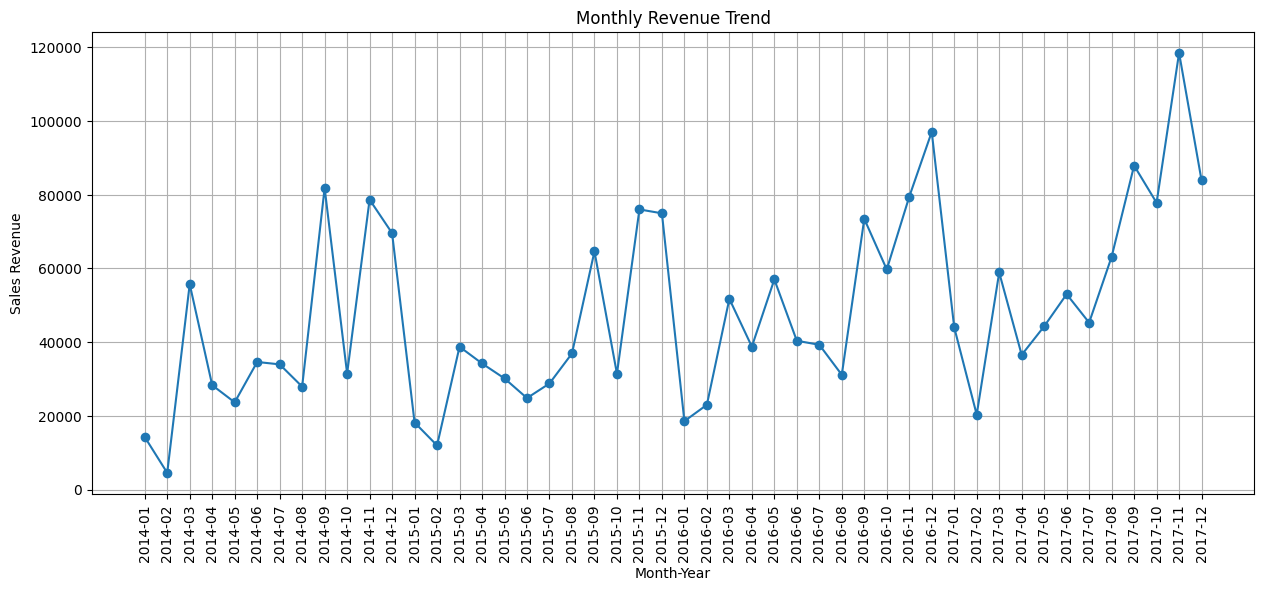

In [15]:
print("--------------Monthly Revenue Trend---------------")
plt.figure(figsize=(15,6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month-Year')
plt.ylabel('Sales Revenue')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

-------------- MONTHLY PROFIT TREND---------------


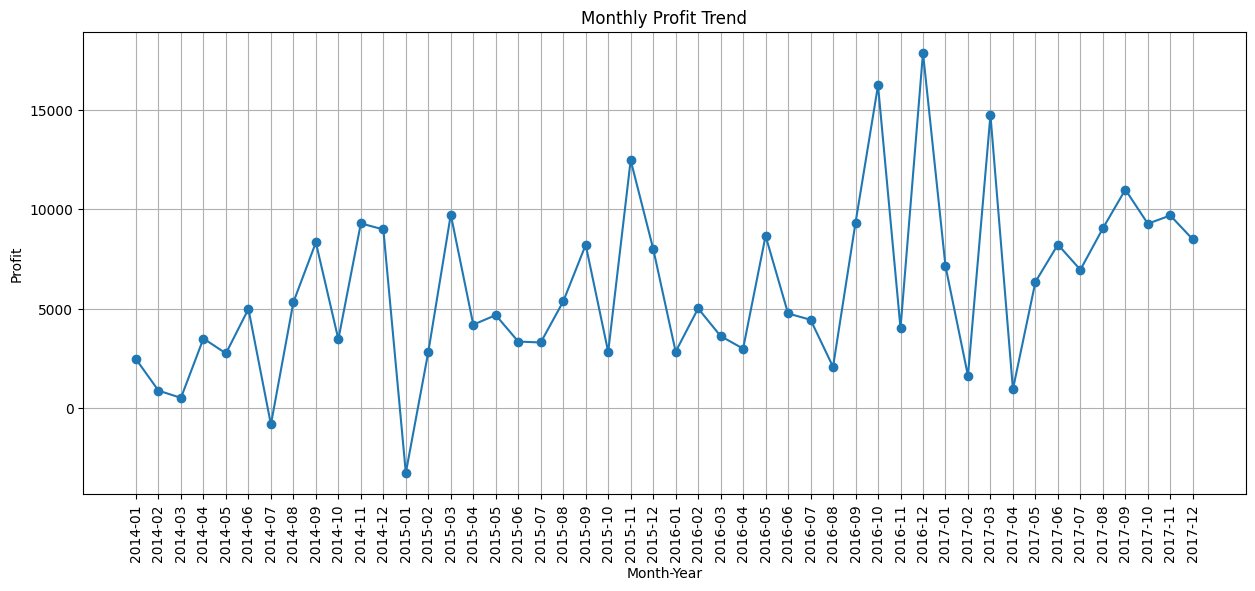

In [16]:
print("-------------- MONTHLY PROFIT TREND---------------")

monthly_profit = df.groupby('Month_Year')['Profit'].sum()
plt.figure(figsize=(15,6))
plt.plot(monthly_profit.index.astype(str), monthly_profit.values, marker='o')
plt.title('Monthly Profit Trend')
plt.xlabel('Month-Year')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [17]:
top_products = df.groupby('Product Name')['Sales'].sum()
top_products = top_products.sort_values(ascending=False).head(10)
print("\nTOP 10 SELLING PRODUCTS")
print("\n")
print(top_products)


TOP 10 SELLING PRODUCTS


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


--------------TOP 10 SELLING PRODUCTS---------------


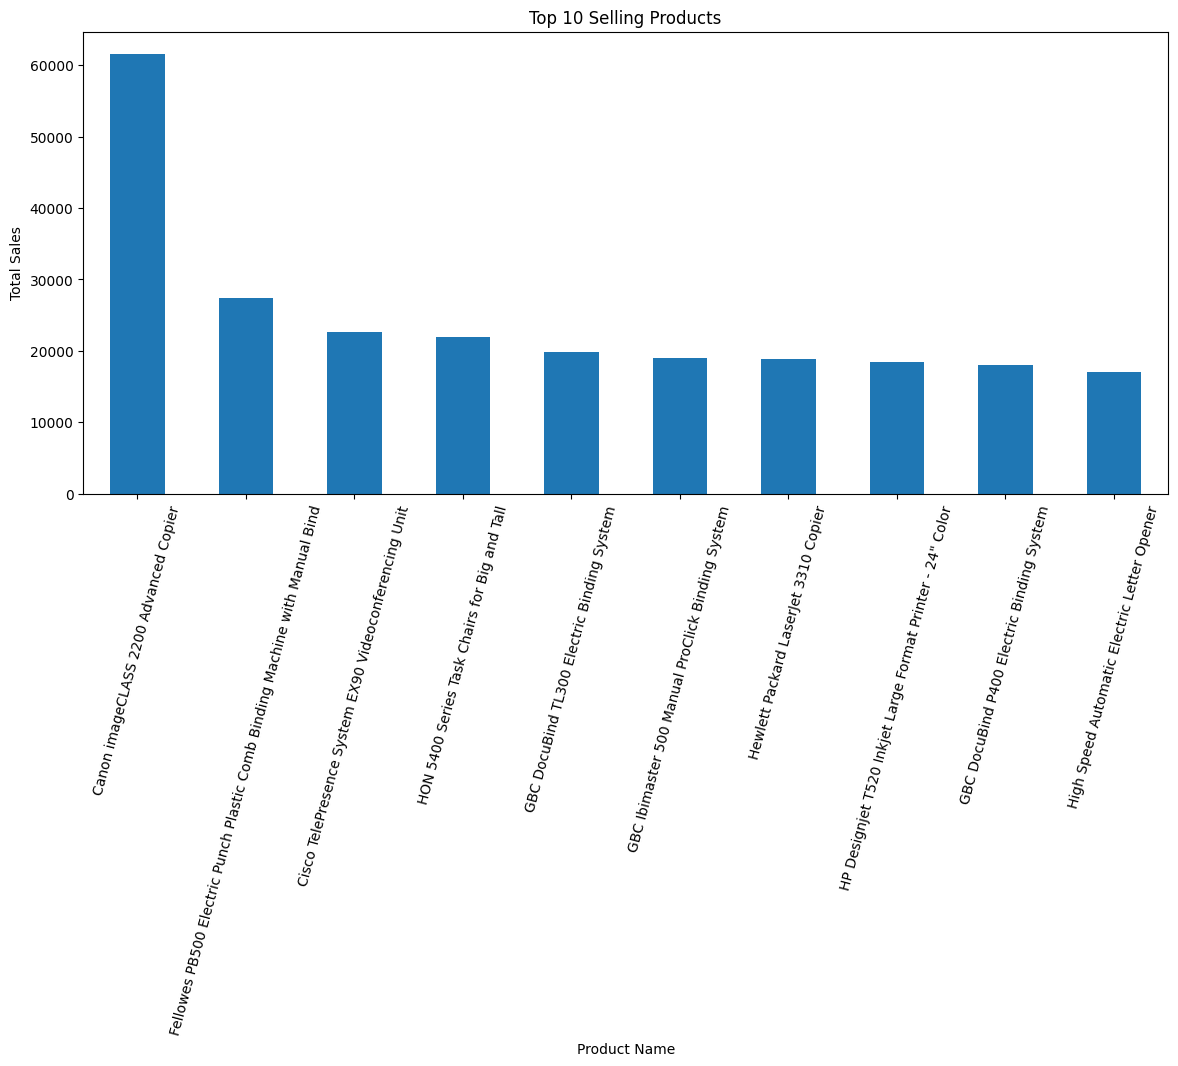

In [18]:
print("--------------TOP 10 SELLING PRODUCTS---------------")
plt.figure(figsize=(14,6))
top_products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=75)
plt.show()

-------------- CATEGORY WISE SALES---------------

CATEGORY WISE SALES
Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


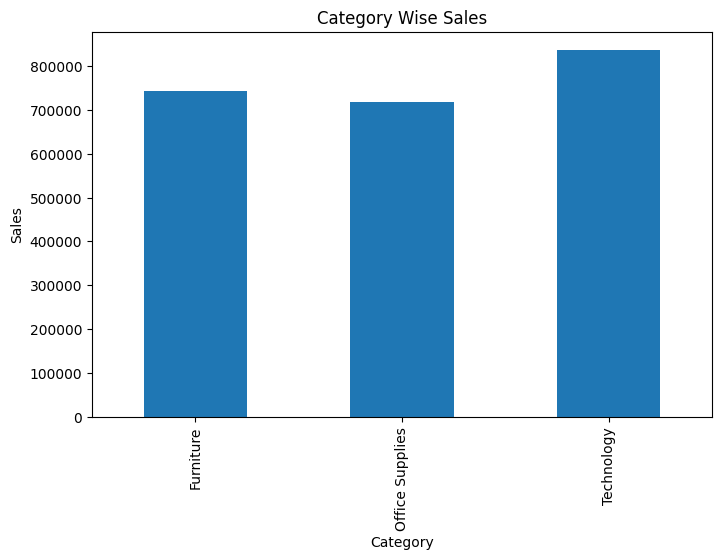

In [19]:
print("-------------- CATEGORY WISE SALES---------------")
category_sales = df.groupby('Category')['Sales'].sum()
print("\nCATEGORY WISE SALES")
print(category_sales)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title('Category Wise Sales')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

----------------CATEGORY WISE PROFIT-----------------

CATEGORY WISE PROFIT
Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64




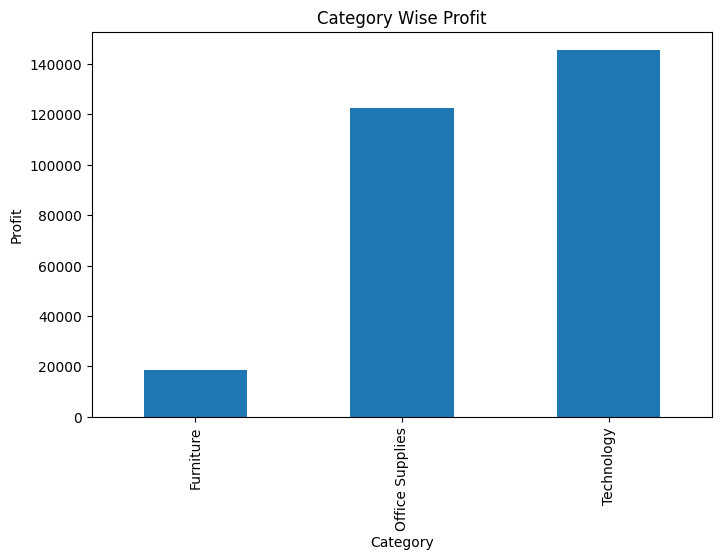

In [20]:
print("----------------CATEGORY WISE PROFIT-----------------")

category_profit=df.groupby('Category')['Profit'].sum()
print("\nCATEGORY WISE PROFIT")
print(category_profit)
print("\n")

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')
plt.title('Category Wise Profit')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()


-----------------SUB-CATEGORY ANALYSIS-------------------

SUB-CATEGORY WISE PROFIT
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


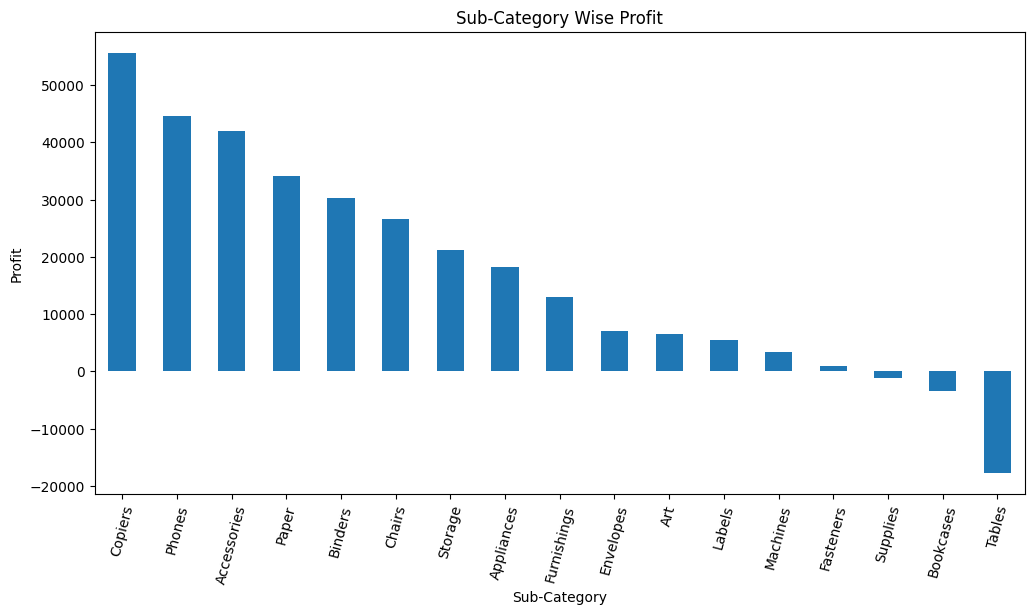

In [21]:
print("-----------------SUB-CATEGORY ANALYSIS-------------------")
subcategory_profit=df.groupby('Sub-Category')['Profit'].sum()
subcategory_profit=subcategory_profit.sort_values(ascending=False)
print("\nSUB-CATEGORY WISE PROFIT")
print(subcategory_profit)
plt.figure(figsize=(12,6))
subcategory_profit.plot(kind='bar')
plt.title('Sub-Category Wise Profit')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=75)
plt.show()

------------------ STATE WISE SALES --------------------

TOP 10 STATES BY SALES
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


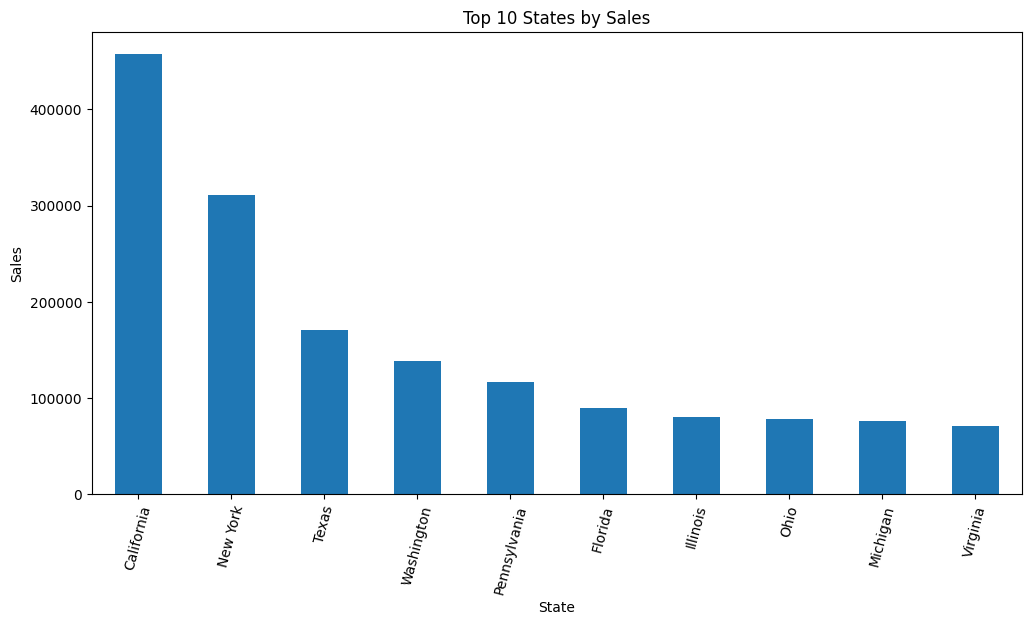

In [22]:
print("------------------ STATE WISE SALES --------------------")
state_sales=df.groupby('State')['Sales'].sum()
state_sales=state_sales.sort_values(ascending=False).head(10)
print("\nTOP 10 STATES BY SALES")
print(state_sales)

plt.figure(figsize=(12,6))
state_sales.plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales')
plt.xticks(rotation=75)
plt.show()

-----------------SHIP MODE ANALYSIS----------------

SHIP MODE ANALYSIS
Ship Mode
First Class       3.514284e+05
Same Day          1.283631e+05
Second Class      4.591936e+05
Standard Class    1.358216e+06
Name: Sales, dtype: float64


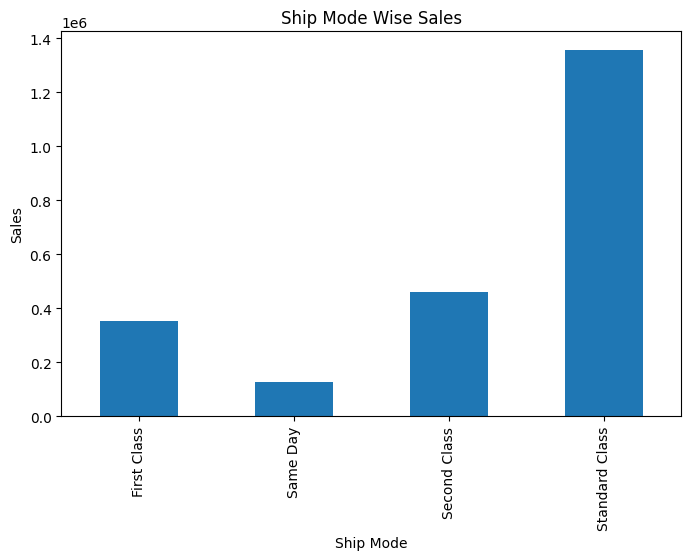

In [23]:
print("-----------------SHIP MODE ANALYSIS----------------")
ship_mode_sales=df.groupby('Ship Mode')['Sales'].sum()
print("\nSHIP MODE ANALYSIS")
print(ship_mode_sales)

plt.figure(figsize=(8,5))
ship_mode_sales.plot(kind='bar')
plt.title('Ship Mode Wise Sales')
plt.xlabel('Ship Mode')
plt.ylabel('Sales')
plt.show()

------------------------CUSTOMER SEGMENT ANALYSIS--------------

CUSTOMER SEGMENT ANALYSIS
Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


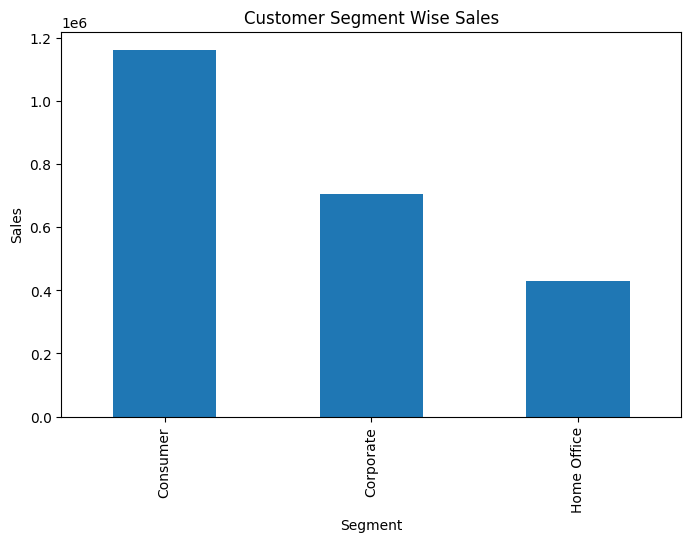

In [24]:
print("------------------------CUSTOMER SEGMENT ANALYSIS--------------")
segment_sales=df.groupby('Segment')['Sales'].sum()
print("\nCUSTOMER SEGMENT ANALYSIS")
print(segment_sales)

plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar')
plt.title('Customer Segment Wise Sales')
plt.xlabel('Segment')
7
plt.ylabel('Sales')
plt.show()

In [23]:
print("--------------DISCOUNT VS PROFIT ANALYSIS---------------------------")
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'],df['Profit'])
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()


In [27]:
print("--------------BUSINESS INSIGHTS REPORT---------------------------")
# Highest Revenue Month
highest_sales_month=monthly_sales.idxmax()
highest_sales_value=monthly_sales.max()
print("\n1. Highest Revenue Month")
print(highest_sales_month,"with sales of",round(highest_sales_value,2))
# Highest Profit Month
highest_profit_month=monthly_profit.idxmax()
highest_profit_value=monthly_profit.max()
print("\n2. Highest Profit Month")
print(highest_profit_month,"with profit of",round(highest_profit_value,2))
# Best Selling Product
best_product=top_products.idxmax()
print("\n3. Best Selling Product")
print(best_product)

# Most Profitable Category
best_category=category_profit.idxmax()
print("\n4. Most Profitable Category")
print(best_category)

# Most Profitable Sub-Category
best_subcategory=subcategory_profit.idxmax()
print("\n6. Most Profitable Sub-Category")
print(best_subcategory)

# Overall Business Performance
print("\n7. Overall Business Performance")
if df['Profit'].sum()>0:print("The business is generating overall profit.")
else:print("The business is running in loss.")

--------------BUSINESS INSIGHTS REPORT---------------------------

1. Highest Revenue Month
2017-11 with sales of 118447.82

2. Highest Profit Month
2016-12 with profit of 17885.31

3. Best Selling Product
Canon imageCLASS 2200 Advanced Copier

4. Most Profitable Category
Technology

6. Most Profitable Sub-Category
Copiers

7. Overall Business Performance
The business is generating overall profit.


In [29]:

print("PROJECT COMPLETED SUCCESSFULLY")
print("===================================================")

PROJECT COMPLETED SUCCESSFULLY
